In [1]:
import torch
from torch import nn
import torch.optim as optim

from torchvision import datasets, models, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import time

In [2]:
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights
from itertools import chain

weights = ResNet18_Weights.DEFAULT

# Normalización estándar de ImageNet para ResNet18.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]


# Transformaciones de entrenamiento para aumentar la variabilidad de las imágenes:
# - RandomResizedCrop: recorta y redimensiona aleatoriamente a 224x224
# - RandomHorizontalFlip: aplica volteo horizontal aleatorio
# - ToTensor: convierte la imagen a tensor
# - Normalize: normaliza con la media y desviación estándar de ImageNet
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

# Transformación de validación del modelo preentrenado.
test_transform = weights.transforms()

# Dataset de entrenamiento con imágenes de gatos y perros.
train_data = datasets.OxfordIIITPet(
    root="data",
    split="trainval",
    download=True,
    transform = train_transform
)

# Dataset de prueba para medir el rendimiento final.
test_data = datasets.OxfordIIITPet(
    root="data",
    split="test",
    download=True,
    transform = test_transform
)

# Cargamos ResNet18 con pesos preentrenados.
model = resnet18(weights=weights)
# Ajustamos la última capa a las 37 clases del dataset.
model.fc = nn.Linear(512, 37)
# Usamos GPU si está disponible.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Congelar toda la red
for parameter in model.parameters():
    parameter.requires_grad = False

# Solo entrenamos el último bloque convolucional.
for parameter in model.layer4.parameters():
    parameter.requires_grad = True
    
# Descongelar únicamente la última capa
for parameter in model.fc.parameters():
    parameter.requires_grad = True
    
# Función de pérdida para clasificación multiclase.
criterion = nn.CrossEntropyLoss()
# Optimizamos solo las capas que sí se entrenan.
optimizer = optim.Adam(chain(model.layer4.parameters(), model.fc.parameters()), lr = 1e-4)

# Batches para entrenar y evaluar el modelo.
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [3]:
def train(model, train_loader, criterion, optimizer, epochs=10, device="cpu"):
    # Mide el tiempo total de entrenamiento.
    inicio = time.time()
    
    model.train() # Activa el modo entrenamiento (BatchNorm, Dropout, etc.)
    
    # Guarda la evolución del loss.
    loss_history = []
    # Guarda la evolución de accuracy.
    accuracy_history = []
    
    for epoch in range(epochs):
        correct = 0 # Cantidad de imágenes clasificadas correctamente.
        total = 0 # Cantidad total de imágenes procesadas.
        total_loss = 0 # Suma del loss de todos los batches de la época.
        
        for images, labels in train_loader:
            images = images.to(device)  # Mueve las imágenes al dispositivo seleccionado (CPU/GPU).
            labels = labels.to(device)  # Mueve las etiquetas al mismo dispositivo para poder compararlas con las predicciones.
            
            optimizer.zero_grad() # Reinicia los gradientes acumulados del paso anterior.
            logits = model(images) # Forward: obtiene los logits del modelo.
            loss = criterion(logits, labels) # Calcula la pérdida comparando logits vs etiquetas reales.
            loss.backward() # Backpropagation: Calcula automáticamente todos los gradientes.
            optimizer.step() # Actualiza pesos de las convoluciones, de las capas densas y bias utilizando esos gradientes.
            
            total_loss += loss.item() # Acumula el loss de este batch.
            predictions = logits.argmax(dim=1) # Elige el logit más grande de cada imagen. Esa será la clase predicha.
            correct += (predictions == labels).sum().item() # Cuenta cuántas imágenes fueron clasificadas correctamente.
            total += labels.size(0) # Acumula la cantidad total de imágenes vistas.

        loss_history.append(total_loss / len(train_loader)) # Loss promedio considerando todos los batches.
        accuracy_history.append(correct / total) # Porcentaje de aciertos sobre todo el dataset.

        print(
            f"Epoch {epoch+1}/{epochs} "
            f"- Loss: {loss_history[-1]:.4f} "
            f"- Accuracy: {accuracy_history[-1]*100:.2f}%"
        )
    
    # Mide el tiempo total de entrenamiento.
    fin = time.time()
    print(f"Tiempo: {fin-inicio:.2f} segundos")
    
    return loss_history, accuracy_history

def evaluate(model, eval_loader, device="cpu"):
    # Mide el tiempo de evaluación.
    inicio = time.time()
    
    model.eval() # Cambia el modelo a modo evaluación
    
    # Contadores para accuracy final.
    correct = 0
    total = 0
    
    with torch.no_grad(): # Desactiva el cálculo de gradientes para ahorrar memoria y computación.
        for images, labels in eval_loader:
            images = images.to(device)  # Mueve las imágenes al dispositivo seleccionado (CPU/GPU).
            labels = labels.to(device)  # Mueve las etiquetas al mismo dispositivo para poder compararlas con las predicciones.

            logits = model(images) # En evaluación solo hacemos forward pass; no actualizamos pesos.

            # La clase predicha vuelve a salir del logit de mayor valor.
            predictions = logits.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
    accuracy = correct / total # Accuracy global sobre todo el loader.
            
    # Tiempo total de evaluación.
    fin = time.time()
    
    print(f"Accuracy: {accuracy*100:.2f}%")   
    print(f"Tiempo: {fin-inicio:.2f} segundos")
          
    return accuracy

In [4]:
loss_history, accuracy_history = train(
    model,
    train_loader,
    criterion,
    optimizer,
    epochs=10,
    device=device
)

Epoch 1/10 - Loss: 1.9593 - Accuracy: 56.79%
Epoch 2/10 - Loss: 0.9040 - Accuracy: 80.19%
Epoch 3/10 - Loss: 0.6921 - Accuracy: 83.51%
Epoch 4/10 - Loss: 0.5708 - Accuracy: 86.03%
Epoch 5/10 - Loss: 0.5055 - Accuracy: 87.28%
Epoch 6/10 - Loss: 0.4399 - Accuracy: 89.08%
Epoch 7/10 - Loss: 0.4151 - Accuracy: 89.92%
Epoch 8/10 - Loss: 0.3944 - Accuracy: 89.46%
Epoch 9/10 - Loss: 0.3619 - Accuracy: 90.57%
Epoch 10/10 - Loss: 0.3533 - Accuracy: 90.60%
Tiempo: 233.64 segundos


In [5]:
acc = evaluate(
    model,
    test_loader,
    device=device
)

Accuracy: 89.67%
Tiempo: 44.02 segundos


## Análisis y visualizaciones del modelo

En esta sección se reutilizan el modelo entrenado, los `DataLoader` existentes y las métricas guardadas durante el entrenamiento para inspeccionar el comportamiento del modelo con distintas visualizaciones.

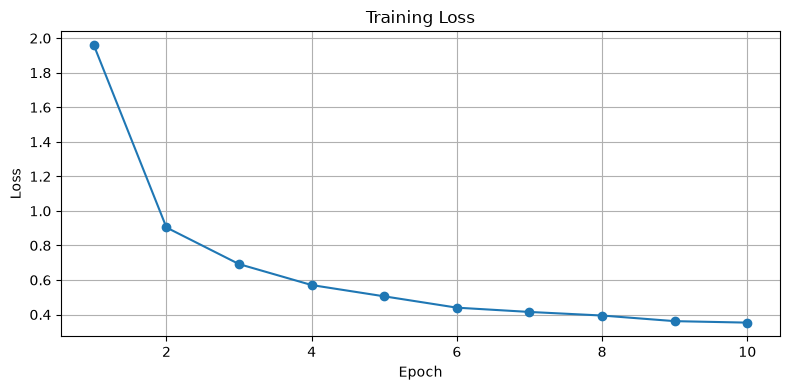

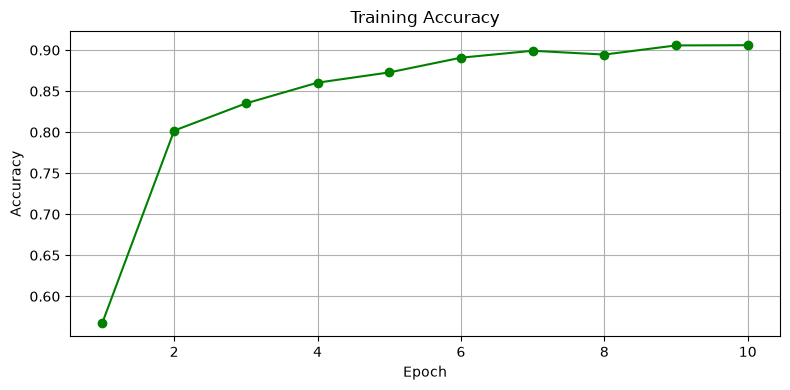

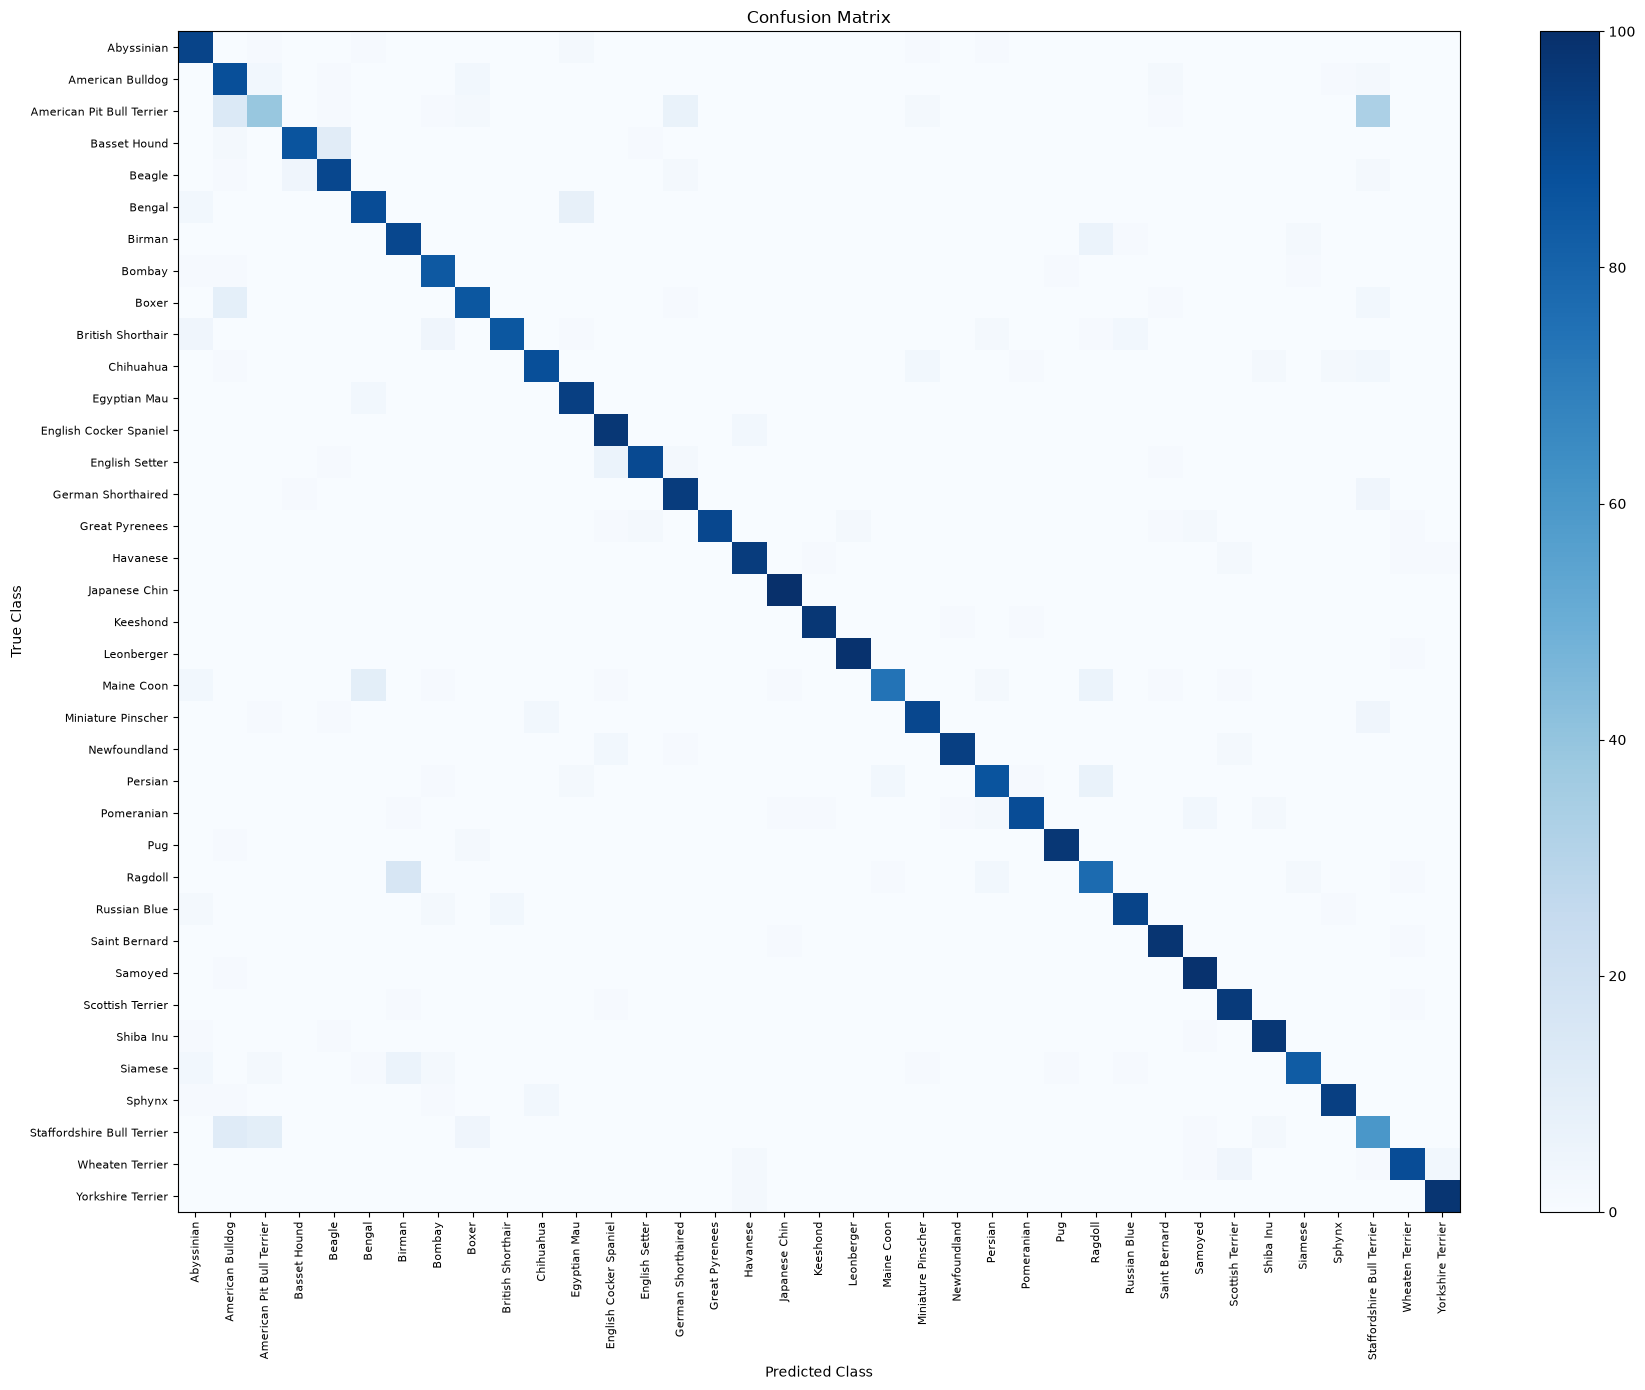

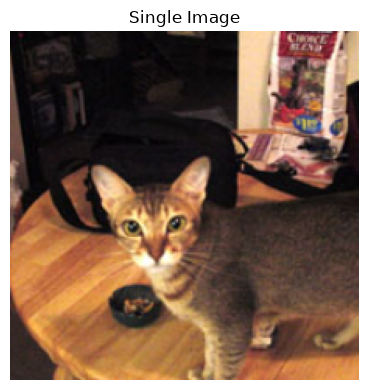

Top-5 Predictions:
1. Abyssinian: 99.83%
2. Bengal: 0.07%
3. Miniature Pinscher: 0.04%
4. Russian Blue: 0.01%
5. Sphynx: 0.01%


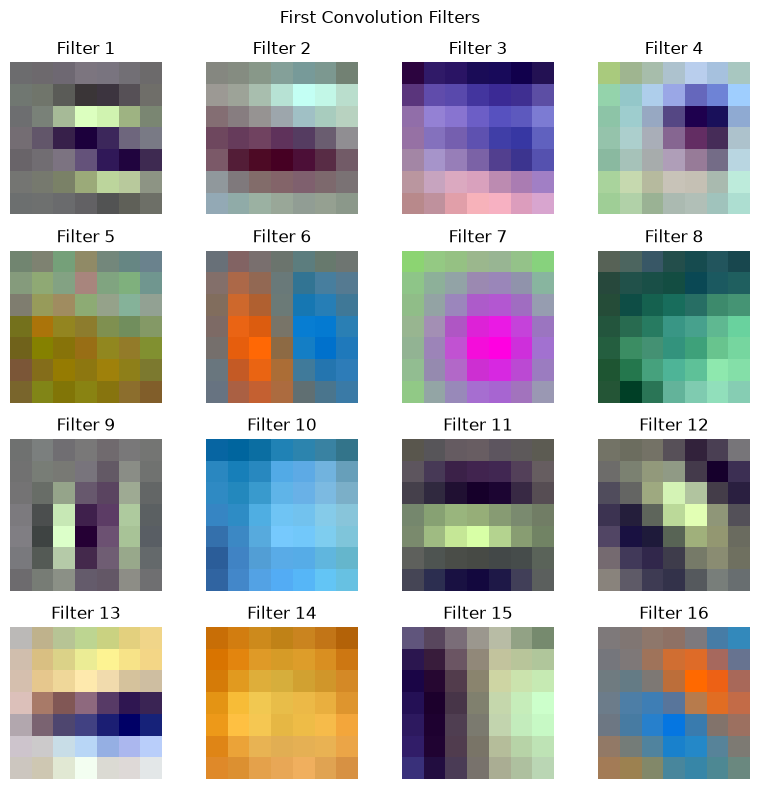

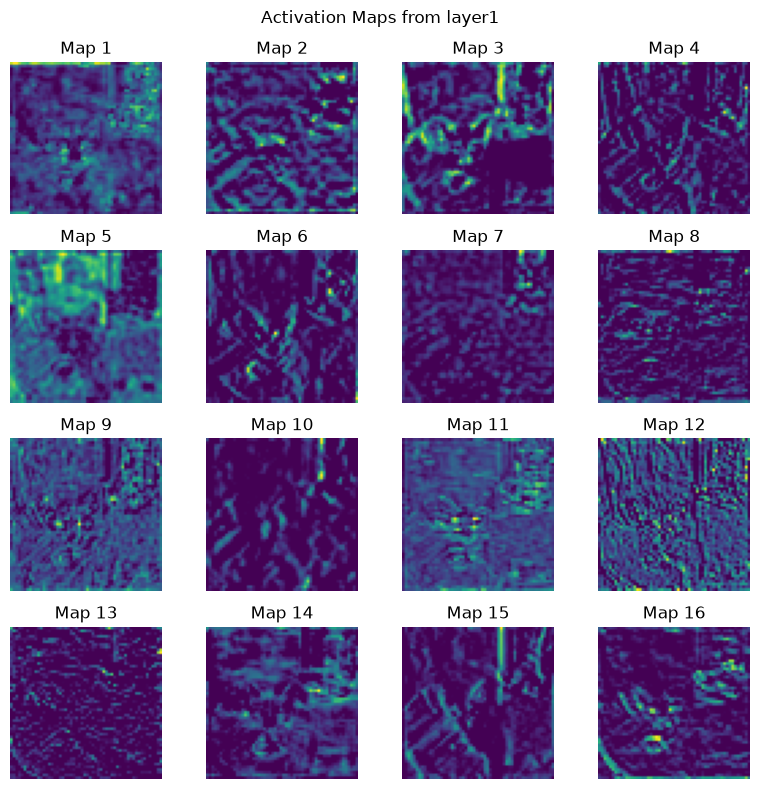

In [7]:
import matplotlib.pyplot as plt
import numpy as np
try:
    import seaborn as sns
except ModuleNotFoundError:
    class _SeabornFallback:
        @staticmethod
        def heatmap(data, cmap="Blues", xticklabels=None, yticklabels=None, cbar=True):
            ax = plt.gca()
            im = ax.imshow(data, cmap=cmap, aspect="auto")
            if cbar:
                plt.colorbar(im, ax=ax)
            if xticklabels is not None:
                ax.set_xticks(np.arange(len(xticklabels)))
                ax.set_xticklabels(xticklabels, rotation=90, fontsize=8)
            if yticklabels is not None:
                ax.set_yticks(np.arange(len(yticklabels)))
                ax.set_yticklabels(yticklabels, rotation=0, fontsize=8)
            return ax

    sns = _SeabornFallback()
from sklearn.metrics import confusion_matrix

# Normalizamos solo para visualización; el modelo sigue recibiendo los tensores ya transformados.
def denormalize_image(image_tensor):
    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std = torch.tensor(imagenet_std).view(3, 1, 1)
    return image_tensor.cpu() * std + mean

# Si el dataset expone nombres de clase, los reutilizamos para los ejes de la matriz de confusión.
class_names = [name.replace("_", " ") for name in getattr(test_data, "classes", [])]
if not class_names:
    class_names = [str(index) for index in range(37)]

# 1. Training Loss
# La curva de pérdida ayuda a ver si el entrenamiento está convergiendo y si la optimización se estabiliza.
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Training Accuracy
# La accuracy muestra qué fracción de imágenes del conjunto de entrenamiento se clasifica correctamente por época.
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(accuracy_history) + 1), accuracy_history, marker="o", color="green")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Confusion Matrix
# Recorremos el test loader para comparar etiquetas reales vs predichas en todo el conjunto de prueba.
model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        predictions = logits.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(18, 14))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# 4. Top-5 Predictions
# Esta función muestra una imagen individual, calcula probabilidades softmax y ordena las 5 clases más probables.
def show_top5_predictions(model, image, class_names, device=device):
    model.eval()

    image_batch = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_batch)
        probabilities = torch.softmax(logits.squeeze(0), dim=0)
        top_probabilities, top_indices = torch.topk(probabilities, 5)

    display_image = denormalize_image(image).clamp(0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(display_image.permute(1, 2, 0))
    plt.title("Single Image")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("Top-5 Predictions:")
    for rank, (index, probability) in enumerate(zip(top_indices.cpu().tolist(), top_probabilities.cpu().tolist()), start=1):
        class_name = class_names[index] if index < len(class_names) else str(index)
        print(f"{rank}. {class_name}: {probability * 100:.2f}%")

    return top_indices, top_probabilities

sample_image, sample_label = test_data[0]
show_top5_predictions(model, sample_image, class_names)

# 5. Visualize First Convolution Filters
# Los filtros de la primera convolución aprenden patrones muy básicos, como bordes, contrastes y texturas de bajo nivel.
first_conv_filters = model.conv1.weight.detach().cpu()
num_filters = min(16, first_conv_filters.shape[0])

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for index, ax in enumerate(axes.flat):
    if index < num_filters:
        filter_tensor = first_conv_filters[index].permute(1, 2, 0)
        normalized_filter = (filter_tensor - filter_tensor.min()) / (filter_tensor.max() - filter_tensor.min() + 1e-8)
        ax.imshow(normalized_filter)
        ax.set_title(f"Filter {index + 1}")
    ax.axis("off")

plt.suptitle("First Convolution Filters")
plt.tight_layout()
plt.show()

# 6. Activation Maps (Forward Hooks)
# Las activation maps muestran qué regiones de la imagen activan con más fuerza una capa intermedia.
activation_maps = {}

def capture_activations(module, module_input, module_output):
    activation_maps["layer1"] = module_output.detach().cpu()

hook_handle = model.layer1.register_forward_hook(capture_activations)

sample_image, _ = test_data[0]
with torch.no_grad():
    _ = model(sample_image.unsqueeze(0).to(device))

hook_handle.remove()

layer_activations = activation_maps["layer1"][0]
num_maps = min(16, layer_activations.shape[0])

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for index, ax in enumerate(axes.flat):
    if index < num_maps:
        ax.imshow(layer_activations[index], cmap="viridis")
        ax.set_title(f"Map {index + 1}")
    ax.axis("off")

plt.suptitle("Activation Maps from layer1")
plt.tight_layout()
plt.show()